## XGBoost Enterprise Pipeline

### CELL 1 — Install

In [8]:
!pip install xgboost -q

### CELL 2 — Imports

In [9]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

### CELL 3 — Load Datasets

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive"
    )
)

True


In [12]:
!ls "/content/drive/MyDrive/Mule Account Detection and Classification/data"

champion_dataset_v1.parquet		selected_dataset_v1.parquet
engineered				test.parquet
enterprise_training_dataset_v1.parquet	train.parquet
investigator_dataset.parquet		validation.parquet
risk_engine_output.parquet


In [13]:
import pandas as pd

PATH = "/content/drive/MyDrive/Mule Account Detection and Classification/data/train.parquet"

df = pd.read_parquet(PATH)

print(df.shape)

(6357, 1001)


In [14]:
import os

ROOT = "/content/drive/MyDrive/Mule Account Detection and Classification"

print("Drive Exists:", os.path.exists("/content/drive"))

print("MyDrive Exists:", os.path.exists("/content/drive/MyDrive"))

print("Project Exists:", os.path.exists(ROOT))

print(
    "Data Exists:",
    os.path.exists(ROOT + "/data")
)

print(
    "Train Exists:",
    os.path.exists(ROOT + "/data/train.parquet")
)

print(
    "Validation Exists:",
    os.path.exists(ROOT + "/data/validation.parquet")
)

print(
    "Test Exists:",
    os.path.exists(ROOT + "/data/test.parquet")
)

Drive Exists: True
MyDrive Exists: True
Project Exists: True
Data Exists: True
Train Exists: True
Validation Exists: True
Test Exists: True


In [15]:
import os

TRAIN_PATH = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"data/train.parquet"
)

VALID_PATH = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"data/validation.parquet"
)

TEST_PATH = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"data/test.parquet"
)

print(f"Checking TRAIN_PATH: {TRAIN_PATH} exists: {os.path.exists(TRAIN_PATH)}")
print(f"Checking VALID_PATH: {VALID_PATH} exists: {os.path.exists(VALID_PATH)}")
print(f"Checking TEST_PATH: {TEST_PATH} exists: {os.path.exists(TEST_PATH)}")

try:
    train_df = pd.read_parquet(TRAIN_PATH)
    valid_df = pd.read_parquet(VALID_PATH)
    test_df = pd.read_parquet(TEST_PATH)

    print(train_df.shape)
    print(valid_df.shape)
    print(test_df.shape)

except FileNotFoundError as e:
    print(f"ERROR: Failed to load data. {e}")
    print("Please ensure the files are present in your Google Drive at the specified paths and that Google Drive is correctly mounted.")
    print("You can verify by navigating to the path in the Google Drive UI or by running `!ls \"/content/drive/MyDrive/Mule Account Detection and Classification/data/\"` in a new cell.")
    # Optionally, you might want to create empty dataframes or set them to None here
    # if you want subsequent cells to run without immediate NameError, but they will likely fail later.
    # For now, we let the exception be caught but provide more context.

Checking TRAIN_PATH: /content/drive/MyDrive/Mule Account Detection and Classification/data/train.parquet exists: True
Checking VALID_PATH: /content/drive/MyDrive/Mule Account Detection and Classification/data/validation.parquet exists: True
Checking TEST_PATH: /content/drive/MyDrive/Mule Account Detection and Classification/data/test.parquet exists: True
(6357, 1001)
(1362, 1001)
(1363, 1001)


### CELL 4 — Split

In [16]:
TARGET = "F3924"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_valid = valid_df.drop(columns=[TARGET])
y_valid = valid_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

### CELL 5 — Calculate Class Weight

In [17]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

110.52631578947368


### CELL 6 — Enterprise XGBoost Model

In [18]:
xgb_model = XGBClassifier(

    n_estimators=1000,

    learning_rate=0.03,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",

    eval_metric="auc",

    random_state=42,

    n_jobs=-1
)

### CELL 7 — Train

In [19]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

### CELL 8 — Validation Prediction

In [20]:
xgb_pred = xgb_model.predict(
    X_valid
)

xgb_prob = (
    xgb_model
    .predict_proba(X_valid)[:,1]
)

### CELL 9 — Validation Metrics

In [21]:
xgb_metrics = {

    "Accuracy":
    accuracy_score(
        y_valid,
        xgb_pred
    ),

    "Precision":
    precision_score(
        y_valid,
        xgb_pred,
        zero_division=0
    ),

    "Recall":
    recall_score(
        y_valid,
        xgb_pred,
        zero_division=0
    ),

    "F1":
    f1_score(
        y_valid,
        xgb_pred,
        zero_division=0
    ),

    "ROC_AUC":
    roc_auc_score(
        y_valid,
        xgb_prob
    )
}

xgb_metrics

{'Accuracy': 0.9992657856093979,
 'Precision': 1.0,
 'Recall': 0.9166666666666666,
 'F1': 0.9565217391304348,
 'ROC_AUC': np.float64(0.9996913580246914)}

### CELL 10 — Confusion Matrix

In [22]:
cm = confusion_matrix(
    y_valid,
    xgb_pred
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual_Normal",
        "Actual_Mule"
    ],
    columns=[
        "Pred_Normal",
        "Pred_Mule"
    ]
)

display(cm_df)

,Pred_Normal,Pred_Mule
Actual_Normal,1350,0
Actual_Mule,1,11


### CELL 11 — Save Confusion Matrix

In [23]:
cm_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_confusion_matrix.csv"
)

### CELL 12 — Classification Report

In [24]:
report_dict = classification_report(
    y_valid,
    xgb_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(report_df)

,precision,recall,f1-score,support
0,0.999260,1.000000,0.999630,1350.000000
1,1.000000,0.916667,0.956522,12.000000
accuracy,0.999266,0.999266,0.999266,0.999266
macro avg,0.999630,0.958333,0.978076,1362.000000
weighted avg,0.999266,0.999266,0.999250,1362.000000


### CELL 13 — Save Classification Report

In [25]:
report_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_classification_report.csv"
)

### CELL 14 — Threshold Optimization

In [26]:
threshold_results = []

for threshold in np.arange(
    0.05,
    1.00,
    0.05
):

    preds = (
        xgb_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "threshold":
        threshold,

        "precision":
        precision_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "recall":
        recall_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "f1":
        f1_score(
            y_valid,
            preds,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,precision,recall,f1
0,0.05,0.705882,1.000000,0.827586
1,0.10,0.785714,0.916667,0.846154
2,0.15,0.916667,0.916667,0.916667
3,0.20,1.000000,0.916667,0.956522
4,0.25,1.000000,0.916667,0.956522
5,0.30,1.000000,0.916667,0.956522
6,0.35,1.000000,0.916667,0.956522
7,0.40,1.000000,0.916667,0.956522
8,0.45,1.000000,0.916667,0.956522
9,0.50,1.000000,0.916667,0.956522


### CELL 15 — Best Threshold

In [27]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

display(best_row)

,3
threshold,0.200000
precision,1.000000
recall,0.916667
f1,0.956522


### CELL 16 — Save Threshold Report

In [28]:
threshold_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_threshold_optimization.csv",

index=False
)

### CELL 17 — Test Prediction

In [29]:
BEST_THRESHOLD = best_row[
    "threshold"
]

test_prob = (
    xgb_model
    .predict_proba(X_test)[:,1]
)

test_pred = (
    test_prob >= BEST_THRESHOLD
).astype(int)

### CELL 18 — Test Metrics

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# NOTE: This cell requires variables defined in preceding cells, specifically:
# - y_test, X_test (from CELL 4 — Split)
# - test_prob, test_pred (from CELL 17 — Test Prediction)
# - xgb_model (from CELL 6 — Enterprise XGBoost Model)
# - BEST_THRESHOLD (from CELL 17 — Test Prediction)
# - pd (from CELL 2 — Imports)
# Please ensure all cells from the beginning of the notebook are run sequentially
# up to CELL 17 before executing this cell.

# Check if required variables are defined before proceeding
if 'y_test' not in globals() or 'test_pred' not in globals() or 'test_prob' not in globals():
    print("ERROR: Required variables (y_test, test_pred, test_prob) are not defined.")
    print("Please ensure all cells from 'CELL 1 — Install' up to 'CELL 17 — Test Prediction' have been executed sequentially.")
else:
    xgb_test_metrics = {

        "Accuracy":
        accuracy_score(
            y_test,
            test_pred
        ),

        "Precision":
        precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),

        "Recall":
        recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),

        "F1":
        f1_score(
            y_test,
            test_pred,
            zero_division=0
        ),

        "ROC_AUC":
        roc_auc_score(
            y_test,
            test_prob
        )
    }

    xgb_test_metrics

### CELL 19 — Save Metrics

In [31]:
pd.DataFrame(
    [xgb_test_metrics]
).to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_metrics.csv",

index=False
)

### CELL 20 — Feature Importance

In [32]:
importance = pd.DataFrame({

    "feature":
    X_train.columns,

    "importance":
    xgb_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(
    importance.head(30)
)

,feature,importance
23,F1273,0.069672
528,F2831,0.026355
21,F2030,0.021438
43,F2036,0.020737
7,F1057,0.019279
815,F3633,0.018738
16,F1166,0.018555
383,F2837,0.017991
17,F949,0.016593
98,F162,0.016438


### CELL 21 — Save Feature Importance

In [33]:
importance.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_feature_importance.csv",

index=False
)

### CELL 22 — Save Model

In [34]:
import os

MODEL_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

xgb_model.save_model(
    MODEL_DIR +
    "/xgboost_model.json"
)

### CELL 23 — Model Summary

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
summary = pd.DataFrame({

    "Model":["XGBoost"],

    "Accuracy":[
        xgb_test_metrics["Accuracy"]
    ],

    "Precision":[
        xgb_test_metrics["Precision"]
    ],

    "Recall":[
        xgb_test_metrics["Recall"]
    ],

    "F1":[
        xgb_test_metrics["F1"]
    ],

    "ROC_AUC":[
        xgb_test_metrics["ROC_AUC"]
    ]
})

summary

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.997799,1.0,0.75,0.857143,0.998581


In [33]:
import matplotlib.pyplot as plt

%matplotlib inline

In [34]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

#ROC Curve

In [12]:
print("xgb_model" in globals())

True


In [11]:
from xgboost import XGBClassifier

MODEL_PATH = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"models/"
"xgboost_model.json"
)

xgb_model = XGBClassifier()

xgb_model.load_model(
    MODEL_PATH
)

print("Model Loaded")

Model Loaded


In [13]:
TEST_PATH = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"data/test.parquet"
)

test_df = pd.read_parquet(TEST_PATH)

print(test_df.shape)

(1363, 1001)


In [14]:
TARGET = "F3924"

# Check if required variables are defined
if 'test_df' not in globals() or 'xgb_model' not in globals():
    print("ERROR: Required variables (test_df, xgb_model) are not defined.")
    print("Please ensure 'CELL 3 — Load Datasets', 'CELL 4 — Split', and 'CELL 6 — Enterprise XGBoost Model' have been executed sequentially.")
else:
    X_test = test_df.drop(
        columns=[TARGET]
    )

    y_test = test_df[TARGET]

    test_prob = (
        xgb_model
        .predict_proba(X_test)[:,1]
    )

    print("Ready")


Ready


In [15]:
print("y_test exists:", "y_test" in globals())
print("test_prob exists:", "test_prob" in globals())

y_test exists: True
test_prob exists: True


In [16]:
from sklearn.metrics import roc_curve
import pandas as pd # Ensure pandas is available for DataFrame

# Check if required variables are defined
if 'y_test' not in globals() or 'test_prob' not in globals():
    print("ERROR: Required variables (y_test, test_prob) are not defined.")
    print("Please ensure 'CELL 4 — Split' and 'CELL 17 — Test Prediction' have been executed sequentially.")
else:
    fpr, tpr, thresholds = roc_curve(
        y_test,
        test_prob
    )

    roc_df = pd.DataFrame({
        "FPR": fpr,
        "TPR": tpr,
        "Threshold": thresholds
    })

    display(roc_df.head())


,FPR,TPR,Threshold
0,0.000000,0.000000,inf
1,0.000000,0.083333,0.999980
2,0.000000,0.833333,0.198625
3,0.002221,0.833333,0.044081
4,0.002221,0.916667,0.043731


In [17]:
roc_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_roc_curve.csv",

index=False
)

print("ROC Curve Saved")

ROC Curve Saved


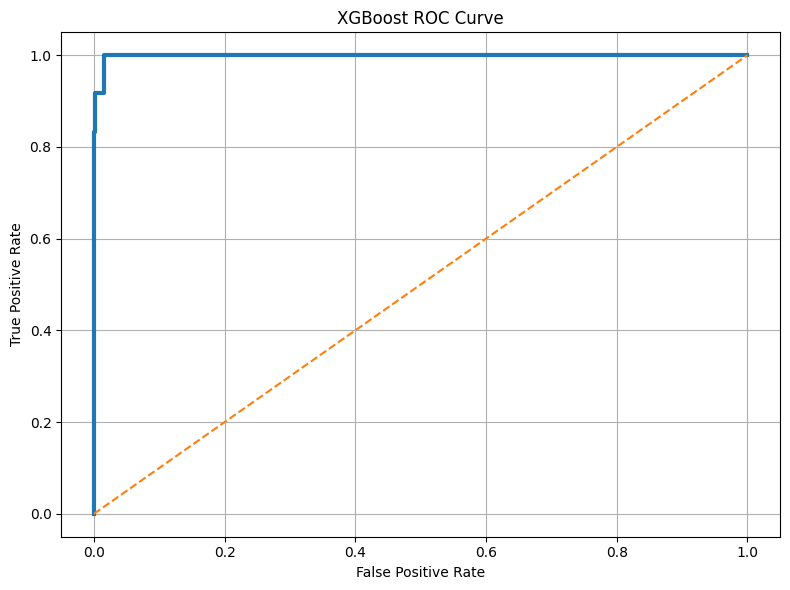

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    roc_df["FPR"],
    roc_df["TPR"],
    linewidth=3
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("XGBoost ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.grid(True)

plt.tight_layout()

plt.show()

#Precision Recall Curve

In [19]:
from sklearn.metrics import precision_recall_curve
import pandas as pd # Ensure pandas is available for DataFrame

(precision,
recall,
thresholds) = precision_recall_curve(
    y_test,
    test_prob
)

pr_df = pd.DataFrame({

    "Precision": precision[:-1],
    "Recall": recall[:-1],
    "Threshold": thresholds
})

display(pr_df.head())


,Precision,Recall,Threshold
0,0.008804,1.0,0.000007
1,0.008811,1.0,0.000007
2,0.008817,1.0,0.000008
3,0.008824,1.0,0.000008
4,0.008830,1.0,0.000009


In [20]:
pr_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_pr_curve.csv",

index=False
)

print("PR Curve Saved")

PR Curve Saved


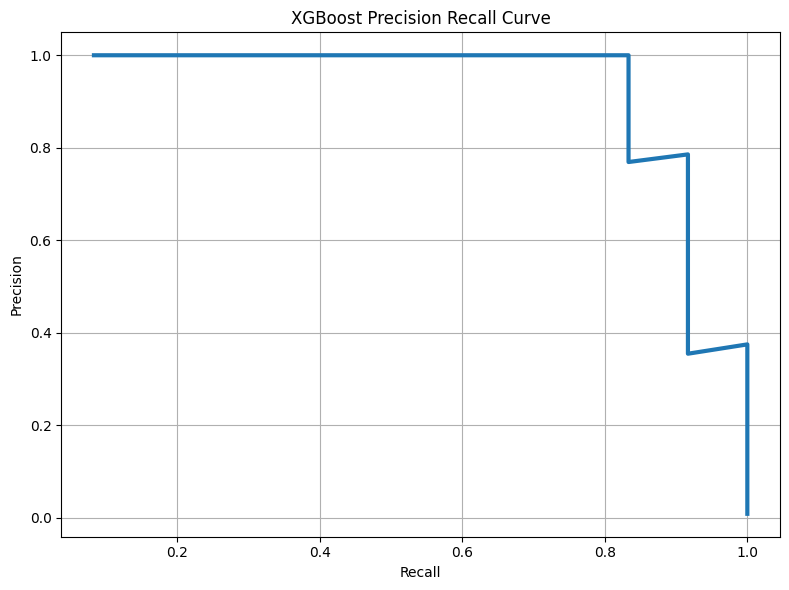

In [38]:
plt.figure(figsize=(8,6))

plt.plot(
    pr_df["Recall"],
    pr_df["Precision"],
    linewidth=3
)

plt.title("XGBoost Precision Recall Curve")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.grid(True)

plt.tight_layout()

plt.show()

#Calibration Curve

In [22]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(

    y_test,

    test_prob,

    n_bins=10
)

In [23]:
calibration_df = pd.DataFrame({

    "Predicted_Probability": prob_pred,

    "Observed_Frequency": prob_true
})

display(calibration_df)

,Predicted_Probability,Observed_Frequency
0,0.000459,0.001480
1,0.164290,0.333333
2,0.274255,1.000000
3,0.749647,1.000000
4,0.998194,1.000000


In [24]:
calibration_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_calibration_curve.csv",

index=False
)

print("Calibration Curve Saved")

Calibration Curve Saved


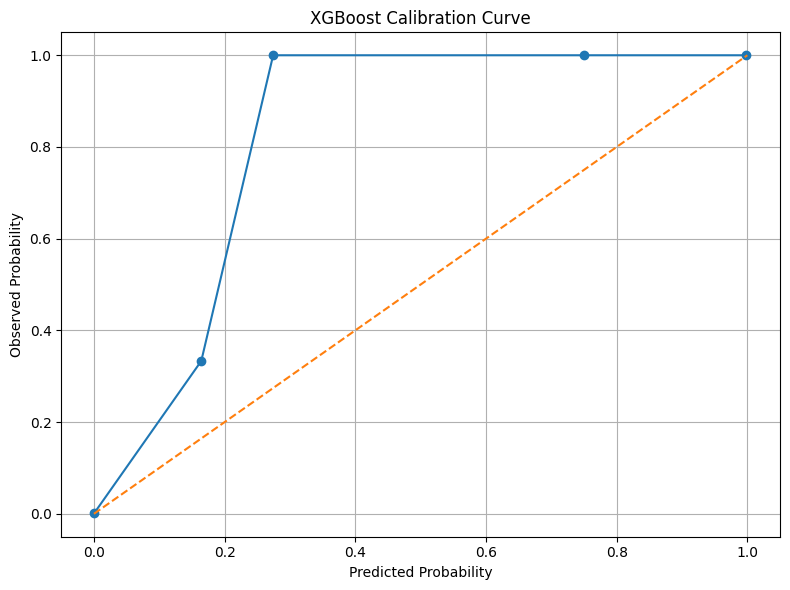

In [40]:
plt.figure(figsize=(8,6))

plt.plot(
    calibration_df["Predicted_Probability"],
    calibration_df["Observed_Frequency"],
    marker="o"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("XGBoost Calibration Curve")

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Probability")

plt.grid(True)

plt.tight_layout()

plt.show()

#Gain Chart

In [25]:
gain_df = pd.DataFrame({

    "actual": y_test,

    "probability": test_prob
})

gain_df = gain_df.sort_values(

    "probability",

    ascending=False
)

gain_df["cum_fraud"] = (

    gain_df["actual"]
    .cumsum()
)

gain_df["gain"] = (

    gain_df["cum_fraud"]

    /

    gain_df["actual"].sum()

    * 100
)

gain_df.head()

,actual,probability,cum_fraud,gain
182,1,0.999980,1,8.333333
103,1,0.999849,2,16.666667
72,1,0.999808,3,25.000000
612,1,0.999747,4,33.333333
301,1,0.999240,5,41.666667


In [26]:
gain_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_gain_chart.csv",

index=False
)

print("Gain Chart Saved")

Gain Chart Saved


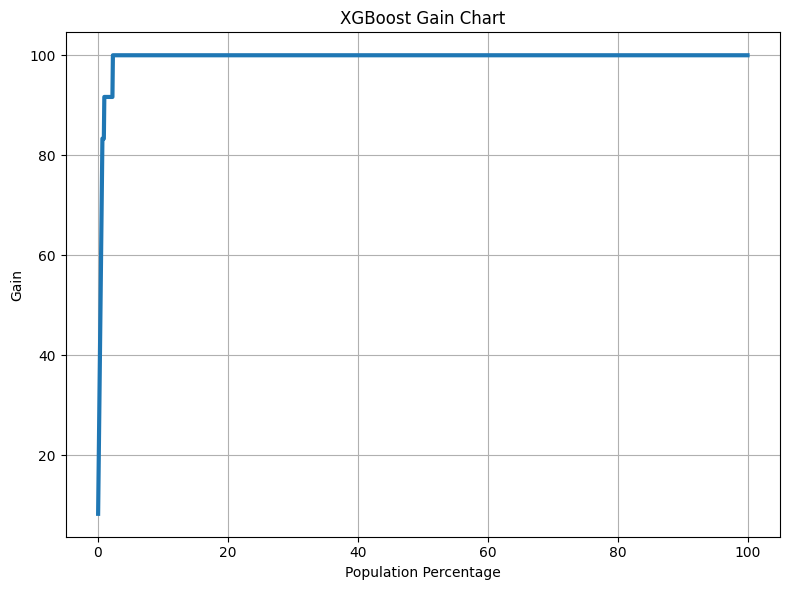

In [42]:
gain_df["population_pct"] = (
    np.arange(
        1,
        len(gain_df)+1
    )
    /
    len(gain_df)
    * 100
)

plt.figure(figsize=(8,6))

plt.plot(
    gain_df["population_pct"],
    gain_df["gain"],
    linewidth=3
)

plt.title("XGBoost Gain Chart")

plt.xlabel("Population Percentage")

plt.ylabel("Gain")

plt.grid(True)

plt.tight_layout()

plt.show()

#Lift Chart

In [28]:
import numpy as np

lift_df = gain_df.copy()

lift_df["population_pct"] = (

    np.arange(
        1,
        len(lift_df)+1
    )

    /

    len(lift_df)

    * 100
)

lift_df["lift"] = (

    lift_df["gain"]

    /

    lift_df["population_pct"]
)

lift_df.head()

,actual,probability,cum_fraud,gain,population_pct,lift
182,1,0.999980,1,8.333333,0.073368,113.583333
103,1,0.999849,2,16.666667,0.146735,113.583333
72,1,0.999808,3,25.000000,0.220103,113.583333
612,1,0.999747,4,33.333333,0.293470,113.583333
301,1,0.999240,5,41.666667,0.366838,113.583333


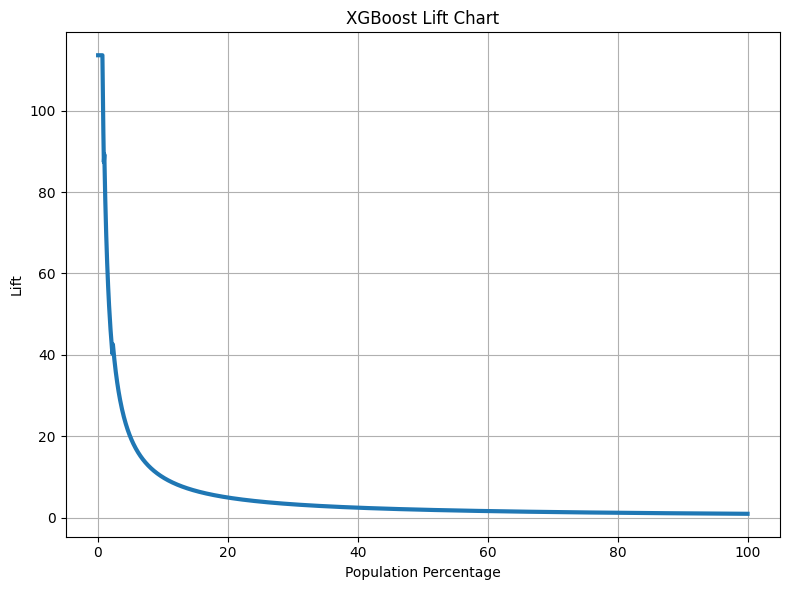

In [44]:
plt.figure(figsize=(8,6))

plt.plot(
    lift_df["population_pct"],
    lift_df["lift"],
    linewidth=3
)

plt.title("XGBoost Lift Chart")

plt.xlabel("Population Percentage")

plt.ylabel("Lift")

plt.grid(True)

plt.tight_layout()

plt.show()

In [29]:
lift_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"xgboost_lift_chart.csv",

index=False
)

print("Lift Chart Saved")

Lift Chart Saved


#Verify Reports

In [30]:
import os

REPORTS = (

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports"
)

for file in os.listdir(REPORTS):

    if "xgboost" in file:

        print(file)

xgboost_confusion_matrix.csv
xgboost_classification_report.csv
xgboost_threshold_optimization.csv
xgboost_metrics.csv
xgboost_feature_importance.csv
xgboost_roc_curve.csv
xgboost_pr_curve.csv
xgboost_calibration_curve.csv
xgboost_gain_chart.csv
xgboost_lift_chart.csv


In [31]:
import os

REPORT_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports"
)

for file in sorted(os.listdir(REPORT_DIR)):
    if "xgboost" in file:
        print(file)

xgboost_calibration_curve.csv
xgboost_classification_report.csv
xgboost_confusion_matrix.csv
xgboost_feature_importance.csv
xgboost_gain_chart.csv
xgboost_lift_chart.csv
xgboost_metrics.csv
xgboost_pr_curve.csv
xgboost_roc_curve.csv
xgboost_threshold_optimization.csv


In [ ]:
plt.savefig(
"/content/drive/MyDrive/Mule Account Detection and Classification/reports/xgboost_roc_curve.png",
dpi=300,
bbox_inches="tight"
)

In [45]:
import os

for file in sorted(os.listdir(REPORT_DIR)):

    if "catboost" in file:

        print(file)

catboost_calibration_curve.csv
catboost_calibration_curve.png
catboost_classification_report.csv
catboost_confusion_matrix.csv
catboost_feature_importance.csv
catboost_gain_chart.csv
catboost_gain_chart.png
catboost_lift_chart.csv
catboost_lift_chart.png
catboost_metrics.csv
catboost_pr_curve.csv
catboost_pr_curve.png
catboost_roc_curve.csv
catboost_roc_curve.png
